In [4]:
import pandas as pd

df = pd.read_csv('loan_prediction.csv')

In [5]:
from google.colab import files
uploaded = files.upload()

Saving loan_prediction.csv to loan_prediction (1).csv


In [6]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


**Encode categorical variables**

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


**Check whether the target is imbalanced**

In [13]:
print(df['Loan_Status'].value_counts())

Loan_Status
1    422
0    192
Name: count, dtype: int64


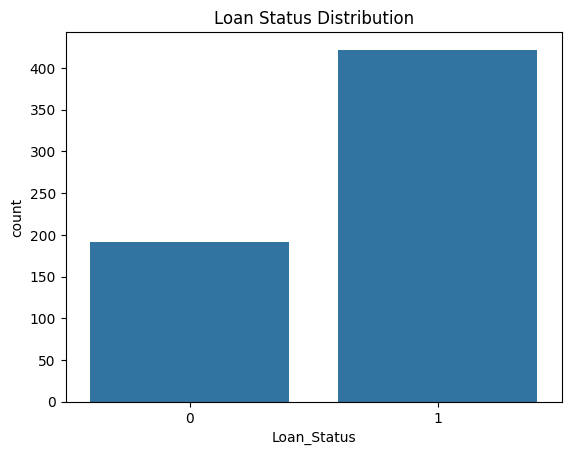

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Loan_Status', data=df)

plt.title('Loan Status Distribution')
plt.show()

**Balance the dataset using SMOTE**

In [15]:
from imblearn.over_sampling import SMOTE

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

smote = SMOTE(random_state=42)

X_balanced, y_balanced = smote.fit_resample(X, y)

print("Before balancing:")
print(y.value_counts())

print("\nAfter balancing:")
print(y_balanced.value_counts())

Before balancing:
Loan_Status
1    422
0    192
Name: count, dtype: int64

After balancing:
Loan_Status
1    422
0    422
Name: count, dtype: int64


**Create a balanced dataframe**

In [16]:
df_balanced = X_balanced.copy()

df_balanced['Loan_Status'] = y_balanced

df_balanced.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


**Observations**

1. The target variable (Loan_Status) was checked for class imbalance.      
2. SMOTE was applied to generate synthetic samples for the minority class.      
3. After balancing, both classes contained equal numbers of samples.          
4. Dataset imbalance was reduced, which can improve model performance.